In [33]:
from pathlib import *
import matplotlib.ticker
import matplotlib.pyplot
import pandas

In [ ]:
# SLO is 500 microseconds
SERVICE_LEVEL_OBJECTIVE = 500

def parse_p99(directory : str) -> pandas.DataFrame:
    rows = []

    for path in Path(directory).iterdir():
        if not path.is_dir():
            continue
        
        log_file_path = path / 'leader.log'
        if not log_file_path.exists():
            continue

        queries_per_second = int(path.name.split("_")[1])

        with open(log_file_path) as log_file:
            raw_data    = log_file.readlines()

            read_p99   = float(raw_data[-11].split()[-1])
            update_p99 = float(raw_data[-10].split()[-1])

            rows.append({
                'qps':        queries_per_second,
                'read_p99':   read_p99,
                'update_p99': update_p99,
            })
    
    return pandas.DataFrame(rows).sort_values('qps').set_index('qps')

def graph_p99(directory : str) -> None:
    data_frame = parse_p99(directory)

    matplotlib.pyplot.figure(figsize=(12, 6))
    matplotlib.pyplot.plot(data_frame['read_p99'],   marker='s')
    matplotlib.pyplot.plot(data_frame['update_p99'], marker='s')
    matplotlib.pyplot.axhline(y=SERVICE_LEVEL_OBJECTIVE, color='r', linestyle='--')
    matplotlib.pyplot.legend(['read_p99', 'update_p99', 'Service Level Objective'])

    matplotlib.pyplot.xlabel("Target QPS")
    matplotlib.pyplot.ylabel("P99 Latency (μs)")

    matplotlib.pyplot.grid(True, axis='both', linestyle='--', alpha=0.5)

    matplotlib.pyplot.gca().xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x) // 1000}K" if x >= 1000 else str(int(x))))

    matplotlib.pyplot.xlim(left=20_000, right=220_000)
    matplotlib.pyplot.ylim(bottom=0, top=1000)

    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

def graph_p99_comparison(experiments : list[tuple[str, str]]) -> None:
    figure, axis = matplotlib.pyplot.subplots(figsize=(12, 6))

    axis.axhline(y=SERVICE_LEVEL_OBJECTIVE, color='r', linestyle='--')
    axis.set_xlabel("Target QPS")
    axis.set_ylabel("P99 Latency (μs)")
    axis.set_xlim(left=20_000, right=220_000)
    axis.set_ylim(bottom=0, top=1000)
    axis.grid(True, axis='both', linestyle='--', alpha=0.5)

    axis.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x) // 1000}K" if x >= 1000 else str(int(x))))

    for (directory, experiment) in experiments:
        data_frame = parse_p99(directory)

        axis.plot(data_frame['read_p99'],   marker='s')
        #axis.plot(data_frame['update_p99'], marker='s')
    
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

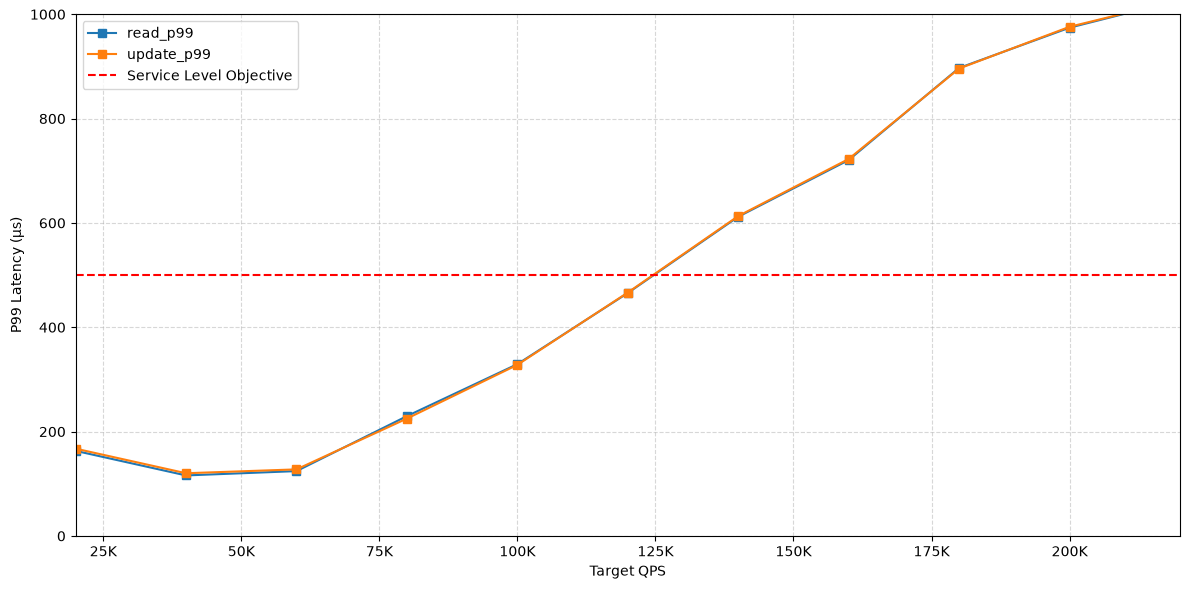

In [48]:
graph_p99("results/run1")

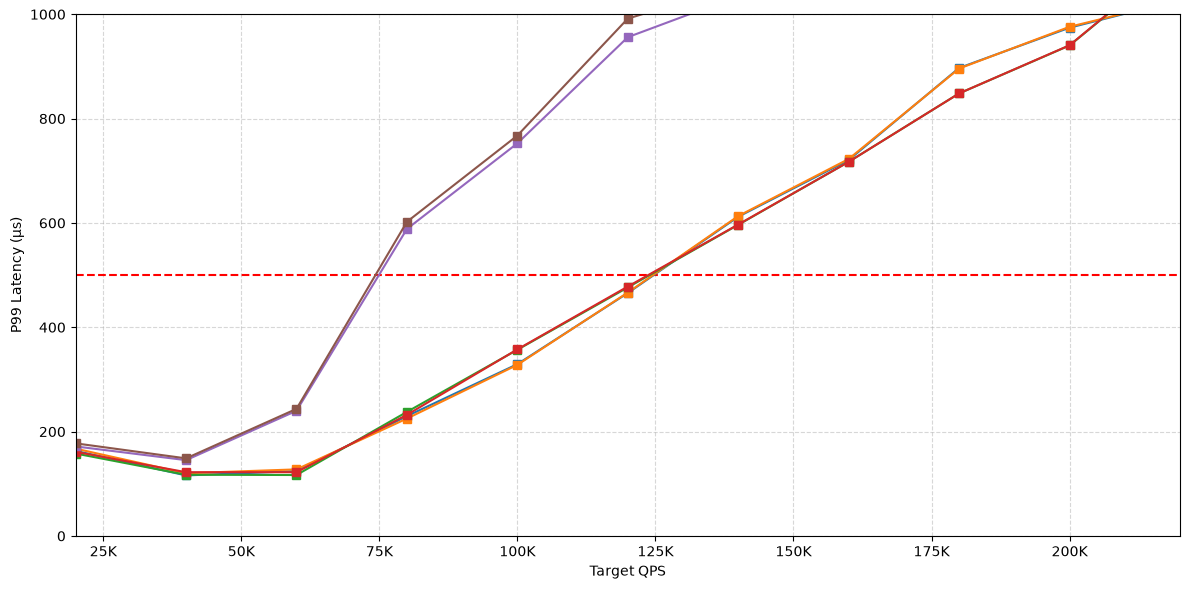

In [49]:
graph_p99_comparison([
    ("results/run1", "Run 1"),
    ("results/run2", "Run 2"),
    ("results/run3", "Run 3"),
])